# Computational Equivalence Benchmark: `pi-oplsda` vs. `ropls`

## Overview
This notebook provides a rigorous mathematical validation of the **`pi-oplsda`** Python package by benchmarking its results against the industry-standard **`ropls`** package from Bioconductor. 

Orthogonal Partial Least Squares Discriminant Analysis (OPLS-DA) is a powerful supervised multi-variate analysis method used in metabolomics to model the relationship between a data matrix $X$ and a class vector $y$. The goal of this benchmark is to demonstrate that `pi-oplsda` achieves numerical identity with `ropls` across all critical model parameters.

---

## Technical Stack
* **Python Environment**: `pi-oplsda` (v1.0.0), `pandas`, `numpy`, `scipy`.
* **R Environment**: `R 4.5.3`, `ropls`.
* **Bridge**: `rpy2` utilizing a robust S4-object extraction strategy to ensure data integrity during cross-language transfer.

---

## Benchmark Dataset: Sacurine
We utilize the **Sacurine** dataset, a gold-standard benchmark in computational metabolomics. 
* **Samples ($n$)**: 183 human urine samples.
* **Features ($p$)**: 109 metabolites (LC-MS positive mode).
* **Target ($y$)**: Biological gender (Male vs. Female).

---

## Validation Metrics
The consistency of the implementation is evaluated across three distinct dimensions:

### 1. Global Model Quality
We compare the summary statistics that define the model's predictive power and fit:
* **$R^2X(cum)$**: Cumulative fraction of the variation of the $X$ matrix explained by the model.
* **$R^2Y(cum)$**: Cumulative fraction of the variation of the $y$ vector explained by the model.
* **$Q^2(cum)$**: Cumulative fraction of the total variation of $y$ predicted by $7$-fold cross-validation.
* **$RMSEE$**: Root Mean Square Error of Estimation.

### 2. Variable Importance
* **VIP (Variable Importance in Projection)**: We validate the VIP scores calculated using the `ropls` specific algorithm to ensure feature selection consistency.

### 3. Latent Space Representation
The OPLS-DA model decomposes the $X$ matrix as follows:
$$X = T_p P_p^T + T_o P_o^T + E$$
Where:
* $T_p, P_p$: Predictive scores and loadings.
* $T_o, P_o$: Orthogonal scores and loadings.
* $E$: Residual matrix.

We calculate the **Pearson Correlation Coefficient** between the Python and R results for these vectors to ensure the latent space projection is identical.

---

> **Note on Mathematical Signage**: 
> In eigen-decomposition based methods, the signs of scores and loadings are arbitrary (subject to $T \cdot P^T$). A correlation of $-1.0$ is mathematically equivalent to $1.0$ in terms of model interpretation. This benchmark accounts for potential sign flips.

In [1]:
import os
import sys
import subprocess
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure R environment for rpy2
# Replace this path with your actual R installation path if needed
R_HOME = "D:/R/R-4.5.3" 
os.environ["R_HOME"] = R_HOME
r_bin = os.path.join(R_HOME, "bin", "x64")
os.environ["PATH"] = r_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

from piopls import OPLSDA, load_sacurine

# Standard styling
sns.set_theme(style="ticks")

In [2]:
from typing import Dict, Any

# 1. Load the built-in sacurine benchmark dataset
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=[0])
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=[0])
y_data = df_Y.iloc[:, 0].values 

# 2. Initialize and fit the Python OPLS-DA model
# We enforce 1 predictive + 1 orthogonal component for strict benchmarking
print("Fitting Python pi-oplsda model...")
model_py = OPLSDA(
    n_ortho=None,
    cv_folds=7,
    max_ortho=10, 
    n_perms=100, 
    n_jobs=-1,
    vip_method='vip4')
model_py.fit_pipeline(df_X, y_data)

# 3. Extract comprehensive Python metrics to match the R dictionary structure
# R2X_comp_[0] is predictive R2X, R2X_comp_[1] is the first orthogonal R2X
metrics_py = {
    "R2X": model_py.get_model_info_df().loc[0,"R2X(cum)"],
    "R2Y": model_py.get_model_info_df().loc[0,"R2Y(cum)"],
    "Q2": model_py.get_model_info_df().loc[0,"Q2(cum)"],
    "RMSEE": model_py.get_model_info_df().loc[0,"RMSEE"],
    "VIP": model_py.vip_ropls_,
    "t_pred": model_py.t_pred_.flatten(),
    "p_pred": model_py.p_pred_.flatten(),
    "t_ortho": model_py.T_ortho_
}

print("Python metrics successfully extracted.")

Fitting Python pi-oplsda model...
Starting parallel permutation test (100 permutations)...


Permutation Test: 100%|███████████████| 100/100 [ETA: 00:00]

Python metrics successfully extracted.


In [3]:
from typing import Dict, Any

print("Fitting R ropls model and extracting multidimensional metrics...")
ropls = importr("ropls")
rpy_conv = (
    ro.default_converter + pandas2ri.converter + numpy2ri.converter
)

# Phase A: Pass data and fit in the specific converter context
with localconverter(rpy_conv):
    r_matrix = ro.conversion.get_conversion().py2rpy(df_X)
    r_group = ro.FactorVector(ro.StrVector(y_data))
    r_na = ro.r('NA_integer_')
    
    ro.r("sink('NUL')")  # Silence R console output
    try:
        model_r = ropls.opls(
            r_matrix, r_group, predI=1, orthoI=r_na, 
            crossvalI=7, permI=100, fig_pdfC="none"
        )
    finally:
        ro.r("sink()")

# Phase B: Extract multiple slots from S4 object
# Extracting Global Summary, VIP, Scores (T), and Loadings (P)
ro.r('''
get_all_metrics <- function(model) {
    list(
        summary = model@summaryDF,
        vip     = model@vipVn,
        t_pred  = model@scoreMN,
        p_pred  = model@loadingMN,
        t_ortho = model@orthoScoreMN,
        p_ortho = model@orthoLoadingMN
    )
}
''')
get_all_metrics = ro.globalenv['get_all_metrics']
res_r_raw = get_all_metrics(model_r)

# Phase C: Convert back to Python objects explicitly
metrics_r = {}

# Convert DataFrame metrics
with localconverter(ro.default_converter + pandas2ri.converter):
    sum_df_r: pd.DataFrame = ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('summary')
    )
    metrics_r["R2X"] = sum_df_r['R2X(cum)'].values[-1]
    metrics_r["R2Y"] = sum_df_r['R2Y(cum)'].values[-1]
    metrics_r["Q2"] = sum_df_r['Q2(cum)'].values[-1]
    metrics_r["RMSEE"] = sum_df_r['RMSEE'].values[-1]

# Convert Vector/Matrix metrics
with localconverter(ro.default_converter + numpy2ri.converter):
    metrics_r["VIP"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('vip')
    ))
    metrics_r["t_pred"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('t_pred')
    )).flatten()
    metrics_r["p_pred"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('p_pred')
    )).flatten()
    metrics_r["t_ortho"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('t_ortho')
    ))

Fitting R ropls model and extracting multidimensional metrics...


## Numerical Consistency check

In [4]:
# Construct Comparison Table
metrics = ["R2X", "R2Y", "Q2", "RMSEE"]
global_comparison = pd.DataFrame({
    "Metric": ["R2X(cum)", "R2Y(cum)", "Q2(cum)", "RMSEE"],
    "Python (pi-oplsda)": [metrics_py[k] for k in metrics],
    "R (ropls)": [metrics_r[k] for k in metrics],
})
global_comparison["Abs_Diff"] = np.abs(
    global_comparison["Python (pi-oplsda)"] - global_comparison["R (ropls)"]
)

print("### Table 1: Global Model Quality Metrics Comparison")
print(global_comparison.to_markdown(index=False))

### Table 1: Global Model Quality Metrics Comparison
| Metric   |   Python (pi-oplsda) |   R (ropls) |    Abs_Diff |
|:---------|---------------------:|------------:|------------:|
| R2X(cum) |             0.275229 |       0.275 | 0.000228712 |
| R2Y(cum) |             0.729833 |       0.73  | 0.000167195 |
| Q2(cum)  |             0.592026 |       0.602 | 0.00997427  |
| RMSEE    |             0.258764 |       0.262 | 0.00323576  |


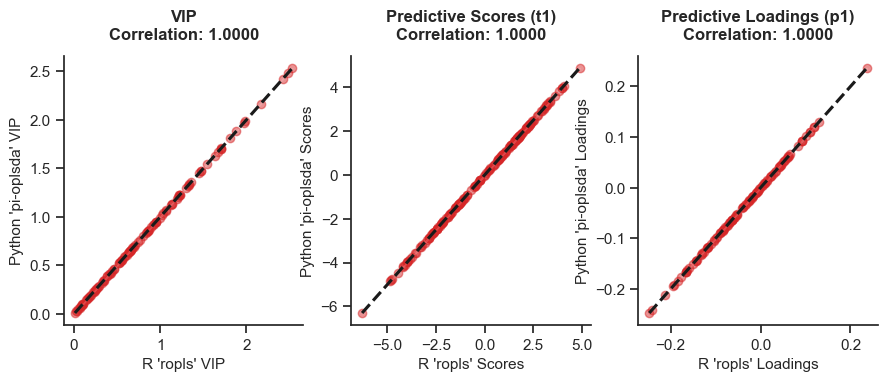

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import List, Any

def plot_triple_comparison(
    py_data: List[np.ndarray], 
    r_data: List[np.ndarray], 
    titles: List[str], 
    labels: List[str]
) -> None:
    """Plots three comparison subplots in a single row for model validation.
    
    Args:
        py_data: List of 1D arrays from the Python 'pi-oplsda' model.
        r_data: List of 1D arrays from the R 'ropls' model.
        titles: List of strings for each subplot title.
        labels: List of strings for axis labels (e.g., 'Scores').
    """
    # Initialize a 1x3 subplot layout
    fig, axes = plt.subplots(1, 3, figsize=(3.5*3, 3.5))
    
    for i in range(3):
        vec_py = py_data[i]
        vec_r = r_data[i]
        ax = axes[i]
        
        # Calculate Pearson correlation to show numerical identity
        corr = np.corrcoef(vec_py, vec_r)[0, 1]
        
        # Draw regression plot; points on diagonal indicate perfect match
        sns.regplot(
            x=vec_r, 
            y=vec_py, 
            ax=ax, 
            color="tab:red",
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'k', 'linestyle': '--'}
        )
        
        ax.set_title(
            f"{titles[i]}\nCorrelation: {corr:.4f}",
            fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel(
            f"R 'ropls' {labels[i]}",fontsize=11, fontweight='normal')
        ax.set_ylabel(
            f"Python 'pi-oplsda' {labels[i]}",fontsize=11, fontweight='normal')
        ax.tick_params(axis='both', labelsize=11)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # plt.tight_layout()
    plt.show()

# 1. Prepare vectorized data from previously extracted metrics
py_vectors = [
    metrics_py["VIP"], 
    metrics_py["t_pred"], 
    metrics_py["p_pred"], 
]

r_vectors = [
    metrics_r["VIP"], 
    metrics_r["t_pred"], 
    metrics_r["p_pred"], 
]

# 2. Define corresponding titles and labels
titles = [
    "VIP",
    "Predictive Scores (t1)", 
    "Predictive Loadings (p1)", 
]
axis_labels= ["VIP", "Scores", "Loadings"]

# 3. Generate the 1x3 comparison visualization
plot_triple_comparison(py_vectors, r_vectors, titles, axis_labels)

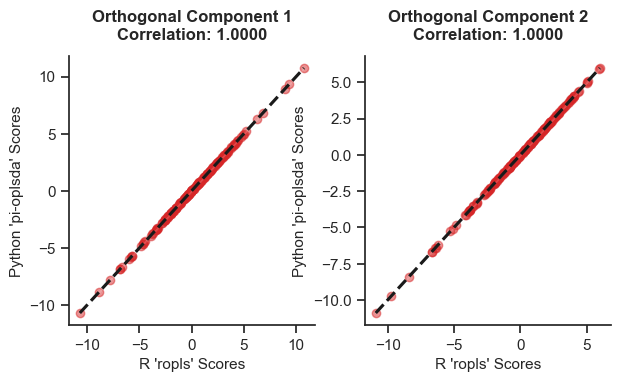

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Any, Tuple

def plot_multidim_orthogonal_comparison(
    py_ortho: np.ndarray, 
    r_ortho: np.ndarray
) -> None:
    """Plots correlation for each orthogonal component in a dynamic grid.
    
    Args:
        py_ortho: Orthogonal scores from 'pi-oplsda' (1D or 2D array).
        r_ortho: Orthogonal scores from 'ropls' (1D or 2D array).
    """
    # Standardize inputs to 2D arrays (N_samples, N_components)
    py_data = (
        py_ortho.reshape(-1, 1) if py_ortho.ndim == 1 else py_ortho
    )
    r_data = (
        r_ortho.reshape(-1, 1) if r_ortho.ndim == 1 else r_ortho
    )

    # Determine the number of components to plot
    n_comp_py = py_data.shape[1]
    n_comp_r = r_data.shape[1]
    n_comp = min(n_comp_py, n_comp_r)

    if n_comp == 0:
        print("No orthogonal components found to plot.")
        return

    # Create a dynamic figure layout (1 row, n_comp columns)
    fig, axes = plt.subplots(
        1, n_comp, figsize=(3.5 * n_comp, 3.5), squeeze=False
    )

    for i in range(n_comp):
        ax = axes[0, i]
        vec_py = py_data[:, i]
        vec_r = r_data[:, i]
        
        # Calculate Pearson correlation coefficient
        correlation = np.corrcoef(vec_py, vec_r)[0, 1]
        
        # Visualize correlation with a regression line
        sns.regplot(
            x=vec_r, 
            y=vec_py, 
            ax=ax, 
            color="tab:red",
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'k', 'linestyle': '--'}
        )
        
        ax.set_title(
            f"Orthogonal Component {i+1}\nCorrelation: {correlation:.4f}",
            fontsize=12, fontweight='bold', pad=12
        )
        ax.set_xlabel("R 'ropls' Scores",fontsize=11, fontweight='normal')
        ax.set_ylabel(
            "Python 'pi-oplsda' Scores",fontsize=11, fontweight='normal')
        ax.tick_params(axis='both', labelsize=11)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        
    plt.show()

# Execution: Pass the extracted orthogonal metrics
# This handles cases whether the model has 1 or multiple orthogonal components
plot_multidim_orthogonal_comparison(
    metrics_py["t_ortho"], 
    metrics_r["t_ortho"]
)